# FastGCN Playground

Right now, we're trying to Frankenstein together GCN, FastGCN and Neuromap somehow 

### To Do:
- sparse_from_igraph analogously to sparse_from_networkx
- Neuromap helper funcs file for our project in src?
- FastGCN helper funcs file for out project in src?


In [1]:
%matplotlib inline

import sys
sys.path.append("..") # go to parent folder

from abc                  import abstractmethod
from numpy                import inf
from torch                import Tensor
from torch.nn             import Parameter
from torch.nn.functional  import softmax, sigmoid
from torch_geometric.nn   import GCN
from torch_geometric.data import Data
from typing               import Dict, List, Tuple

import networkx as nx
import torch
import matplotlib.pyplot as plt
import numpy as np
import time
import seaborn           as sb
import scipy


import torch_geometric.utils as utils
import torch_geometric.transforms as T
import igraph as ig
import networkx as nx
from torch.nn import Linear
from torch_geometric.nn import GCNConv
from torch_geometric.utils import to_networkx

In [2]:
# Prefer CUDA if available, else MPS (Apple Silicon), else CPU
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    
print("Device:", device)

Device: cpu


some helper funcs:

In [3]:
def visualize_graph(G, color):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    nx.draw_networkx(G, pos=nx.spring_layout(G, seed=42), with_labels=False,
                     node_color=color, cmap="Set2")
    plt.show()


def visualize_embedding(h, color, epoch=None, loss=None):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])
    h = h.detach().cpu().numpy()
    plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2")
    if epoch is not None and loss is not None:
        plt.xlabel(f'Epoch: {epoch}, Loss: {loss.item():.4f}', fontsize=16)
    plt.show()


def plot_overlapping(G, S, eps = 1e-3, pos = None, figsize = (5,5), node_scale = 1.0, node_palette = sb.color_palette("colorblind"), link_palette = sb.color_palette("pastel")):
    if pos is None:
        pos = nx.kamada_kawai_layout(G)
        pos = { k:(x,-y) for k,(x,y) in pos.items() }

    A = torch.tensor(nx.adjacency_matrix(G, nodelist = sorted(G.nodes)).todense(), dtype=torch.float)
    p = torch.sum(A, dim = 1) / torch.sum(A)

    existing_modules = []

    for module_ix, total_assignments in enumerate(torch.sum(S,0).numpy()):
        if total_assignments > eps:
            existing_modules.append(module_ix)

    S_reduced = S[:,existing_modules]

    fig, ax = plt.subplots(1, 1, figsize = figsize)

    modules = dict()

    for ix,node in enumerate(sorted(G.nodes())):
        assignment = np.array([s if s > eps else 0 for s in S_reduced[ix].numpy()])
        modules[node] = assignment / sum(assignment)

    edgelist     = []
    edge_colours = []
    edge_widths  = []
    for (u,v) in G.edges:
        edgelist.append((u,v))
        edge_colours.append([link_palette[m % len(link_palette)] for m,s in enumerate(modules[u]) if s > 0][0] if all(modules[u] == modules[v]) else "grey")
        d = G.get_edge_data(u,v)
        edge_widths.append(d["weight"] if "weight" in d else 1)
        
    nx.draw_networkx_edges( G = G
                          , pos = pos
                          , nodelist = sorted(G.nodes)
                          , edgelist = edgelist
                          , width = edge_widths
                          , edge_color = edge_colours
                          , ax = ax
                          , min_source_margin = 1
                          , min_target_margin = 1
                          , arrows = True
                          , connectionstyle = "arc3,rad=0.1"
                          )

    for ix,node in enumerate(sorted(G.nodes())):
        assignment = modules[node]
        ax.pie( [s for s in assignment if s > 0] # flows
              , colors = [node_palette[m % len(node_palette)] for m,s in enumerate(assignment) if s > 0]
              , center = pos[node]
              , radius = 0.25 * np.sqrt(float(p[ix])) * node_scale
              , startangle = 0 # startangle
              , wedgeprops = { "linewidth": 1, "edgecolor": "white" }
              )
    plt.autoscale()

    plt.tight_layout()


def plot_S(S, G):
    fig, ax = plt.subplots(1,1,figsize=(6,5))
    sb.heatmap(S, cmap = sb.color_palette("viridis", as_cmap=True), ax = ax)
    ax.set_xlabel("module")
    ax.set_ylabel("node")
    plt.show()

Mayyyybe let's start with a super simple, basic application of FastGCN, just using the KarateClub dataset:

In [4]:
from torch_geometric.datasets import KarateClub

dataset = KarateClub()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Dataset: KarateClub():
Number of graphs: 1
Number of features: 34
Number of classes: 4


In [5]:
data = dataset[0]
print(data) #edge_index holds src dst node indices
# Gather some statistics about the graph.
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Number of nodes: 34
Number of edges: 156
Average node degree: 4.59
Number of training nodes: 4
Training node label rate: 0.12
Has isolated nodes: False
Has self-loops: False
Is undirected: True


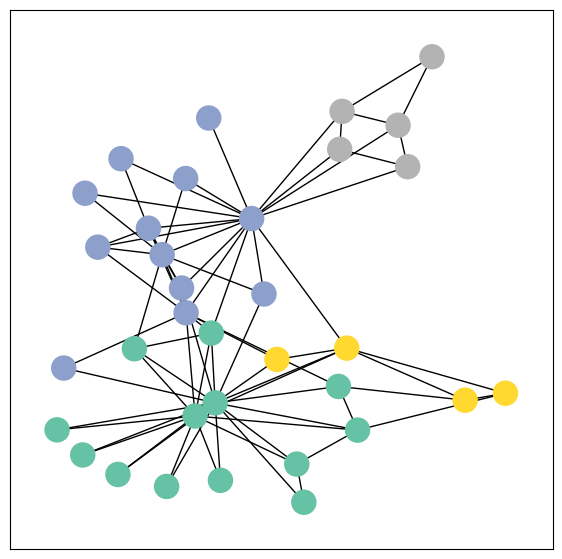

In [6]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
visualize_graph(G, color=data.y)

### GCN: Supervised community detection (Karate club)
First, let's use a super normal GCN:

It has 3 graph convolution layers, which corresponds to aggregating 3-hop neighborhood information around each node (all nodes up to 3 "hops" away). In addition, the GCNConv layers reduce the node feature dimensionality to 2, i.e., 34→4→4→2. Each GCNConv layer is enhanced by a tanh non-linearity.

In [7]:
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GCNConv(dataset.num_features, 4)
        self.conv2 = GCNConv(4, 4)
        self.conv3 = GCNConv(4, 2)
        self.classifier = Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.
        
        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h # return both classification out and node embeddings h

model = GCN()
print(model)

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


Embedding shape: [34, 2]


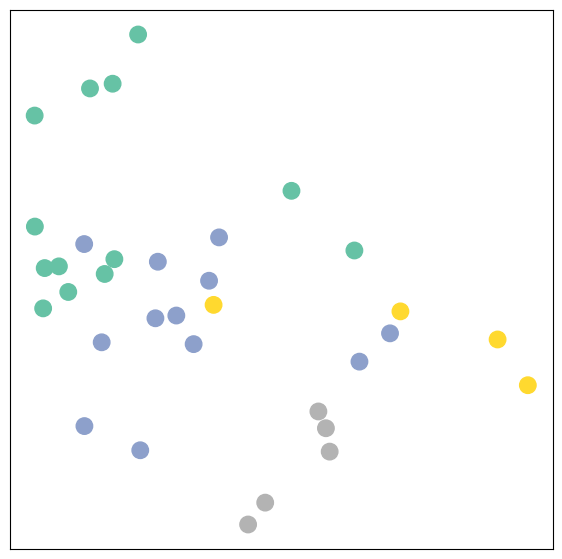

In [8]:
model = GCN()

_, h = model(data.x, data.edge_index)
print(f'Embedding shape: {list(h.shape)}')

visualize_embedding(h, color=data.y)

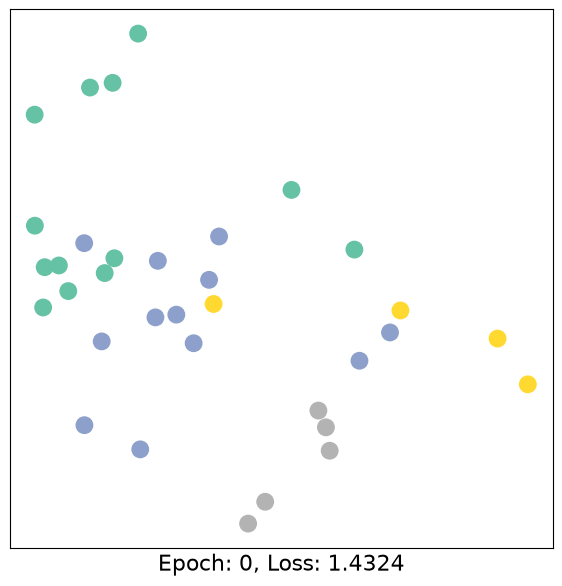

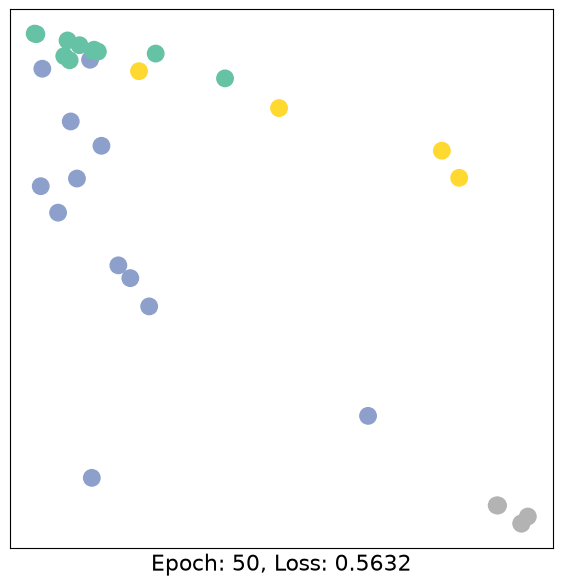

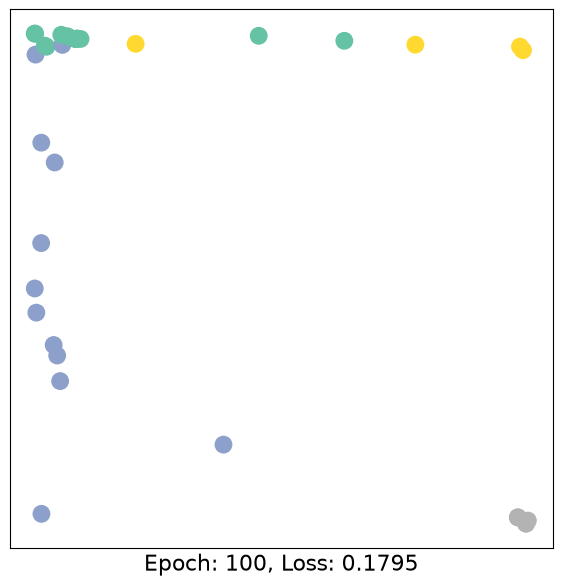

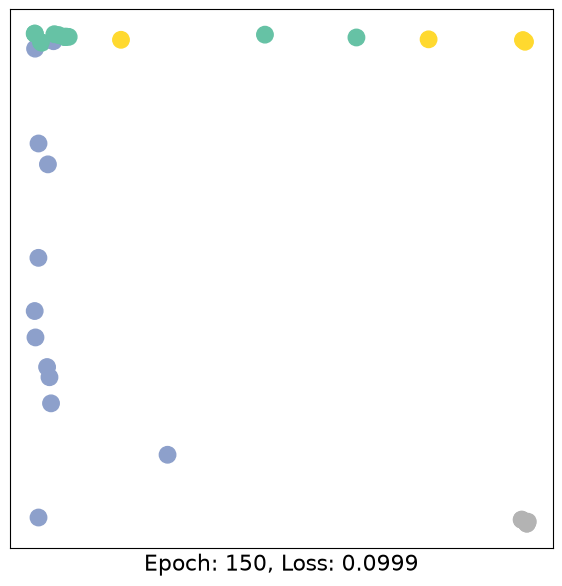

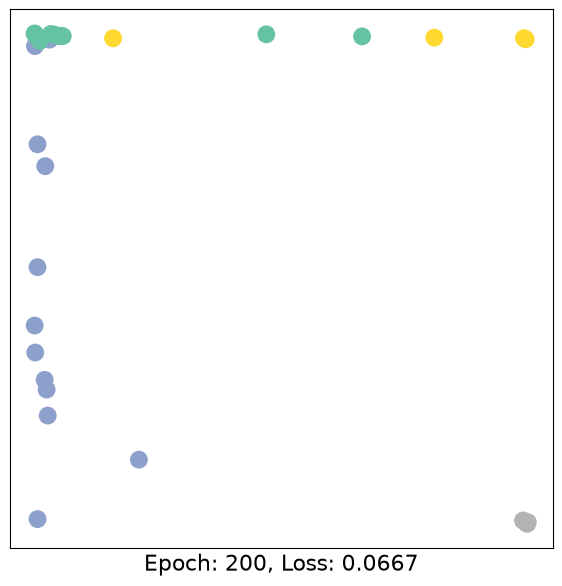

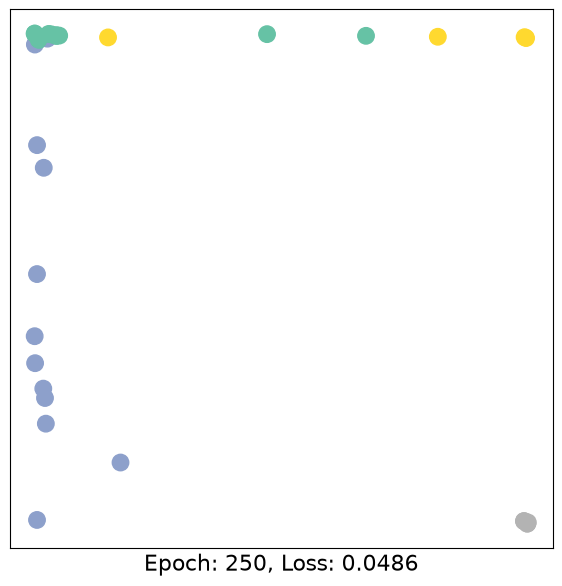

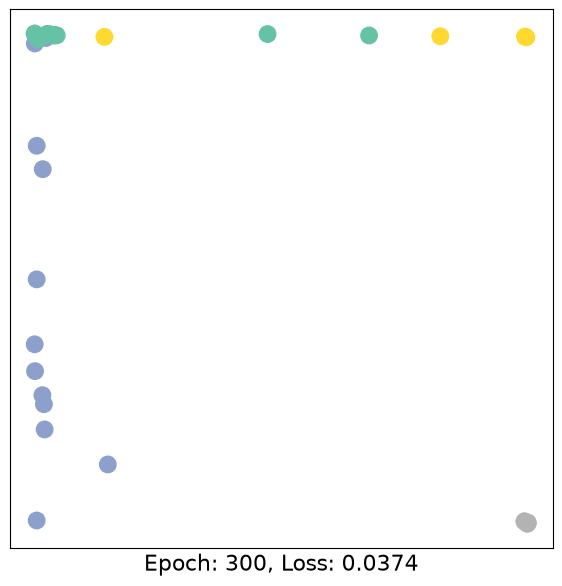

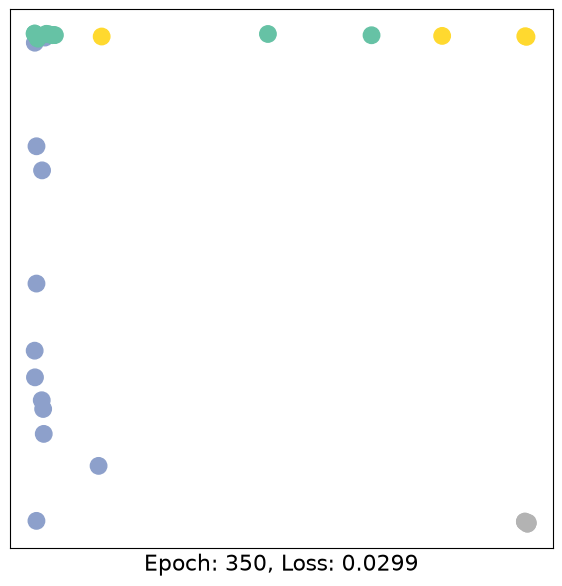

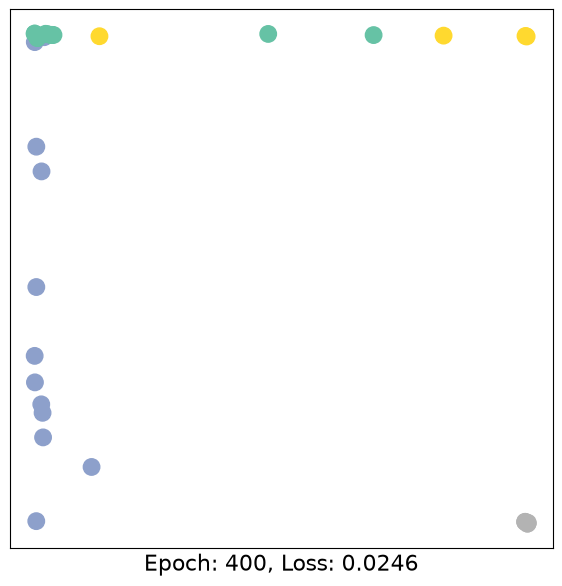

In [9]:
criterion = torch.nn.CrossEntropyLoss()  # Define loss criterion.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Define optimizer.

def train(data):
    optimizer.zero_grad()  # Clear gradients.
    out, h = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss, h

for epoch in range(401): # train 400 epochs
    loss, h = train(data)
    if epoch % 50 == 0:
        visualize_embedding(h, color=data.y, epoch=epoch, loss=loss)
        time.sleep(0.3) #why???????

In [10]:
def test():
      model.eval()
      out, _ = model(data.x, data.edge_index)
      pred = out.argmax(dim=1)  # Use the class with highest probability.
      test_correct = pred[~data.train_mask] == data.y[~data.train_mask]  # Check against ground-truth labels.
      test_acc = int(test_correct.sum()) / int((~data.train_mask).sum())  # Derive ratio of correct predictions.
      return test_acc

test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8000


## GCN with Neuromap on Karate Club
Now for community detection with Neuromap!!

In [11]:
# create smart teleportation flow matrix and flow distribution as described
#  - https://arxiv.org/abs/2311.04036
#  - https://www.nature.com/articles/ncomms5630
def mkSmartTeleportationFlow(A, alpha = 0.15, iter = 1000, device : str = "cpu"):
    # build the transition matrix
    T = torch.nan_to_num(A.T * (torch.sum(A, 1)**(-1.0)).to_dense(), nan = 0.0).T.to(device = device)

    # distribution according to nodes' in-degrees
    e_v = (torch.sum(A, dim = 0) / torch.sum(A)).to_dense().to(device = device)

    # calculate the flow distribution with a power iteration
    p = e_v
    for _ in range(iter):
        p = alpha * e_v + (1-alpha) * p @ T
    
    # make the flow matrix for minimising the map equation
    F = alpha * A / torch.sum(A) + (1-alpha) * (p * T.T).T
    
    return F, p

In [12]:
# We encode the map equation loss in a pooling operator, but are actually
# only interested in the codelength for now
class MapEquationPooling(torch.nn.Module):
    def __init__(self, adj: Tensor, device : str = "cpu", *args, **kwargs) -> None:
        super().__init__(*args, **kwargs)

        self.adj       = adj
        self.F, self.p = mkSmartTeleportationFlow(self.adj, device = device)

        # this term is constant, so only calculate it once
        self.p_log_p = torch.sum(self.p * torch.nan_to_num(torch.log2(self.p), nan = 0.0))

    def forward(self, x, s):
        C      = s.T @ self.F @ s
        diag_C = torch.diag(C)

        q   = 1.0 - torch.trace(C)
        q_m = torch.sum(C, dim = 1) - diag_C
        m_exit = torch.sum(C, dim = 0) - diag_C
        p_m = q_m + torch.sum(C, dim = 0)

        codelength = torch.sum(q      * torch.nan_to_num(torch.log2(q),      nan = 0.0)) \
                   - torch.sum(q_m    * torch.nan_to_num(torch.log2(q_m),    nan = 0.0)) \
                   - torch.sum(m_exit * torch.nan_to_num(torch.log2(m_exit), nan = 0.0)) \
                   - self.p_log_p \
                   + torch.sum(p_m    * torch.nan_to_num(torch.log2(p_m),    nan = 0.0))

        x_pooled   = torch.matmul(s.T, x)
        adj_pooled = s.T @ self.adj @ s

        return x_pooled, adj_pooled, codelength

In [13]:
def sparse_from_networkx(G : nx.Graph) -> Tuple[torch.Tensor, Dict[int, int]]:
    """
    Converts a networkx graph to a sparse tensor.

    Parameters
    ----------
    G : nx.Graph
        The networkx graph, which can be weighted and/or directed.

    Returns
    ------
    Tuple[torch.Tensor, Dict[int, int]]
        A tuple containing the sparse tensor representation of the input graph
        and a dictionary from zero-based IDs to the original node names.
    """

    # always make sure to sort the nodes so they're in the expected order
    the_nodes  = list(sorted(G.nodes))
    node_to_ID = { node:ID for (ID,node) in enumerate(the_nodes) }
    ID_to_node = { ID:node for (ID,node) in enumerate(the_nodes) }

    indices = [[],[]]
    values  = []
    for u in the_nodes:
        for v in sorted(G.neighbors(u)): # again, always sorting...
            weight = 1.0
            data   = G.get_edge_data(u, v)
            if "weight" in data:
                weight = data["weight"]
            indices[0].append(node_to_ID[u])
            indices[1].append(node_to_ID[v])
            values.append(float(weight))
    
    return ( torch.sparse_coo_tensor( indices = indices
                                    , values  = values
                                    , size    = (len(the_nodes), len(the_nodes))
                                    )
           , ID_to_node
           )

In [14]:
def to_dataset(G: nx.Graph, y_true: List[int]) -> Data:
    """
    Takes a networkx graph and a list of community labels for the nodes and
    returns them as a pyg Data representation.

    Parameters
    ----------
    G : nx.Graph
        The networkx graph.

    y_true : List[int]
        List of the nodes' community labels.

    Returns
    -------
    Data
        A Data object where the edge index and node features X are a sparse
        tensor representation of the graph's adjacency matrix and the node
        labels a the nodes' true communities.
    """
    data = Data()
    data.edge_index = sparse_from_networkx(G)[0].coalesce()
    data.x          = sparse_from_networkx(G)[0].coalesce()
    data.y          = torch.Tensor(y_true).long()

    return data

These are slightly simplified, and the neuromap repo contains the more specific version where the different models have already been prepped such that they can simply be called with a string, which I don't think we will use anyways.

In [15]:
# A clusterer that runs the optimisation.
# The missing ingredient: a specific forward method (next cell).
class Clusterer(torch.nn.Module):
    def __init__(self, model, device: str = "cpu") -> None:
        super().__init__()

        self.model  = model
        self.device = device

    @abstractmethod
    def forward(self, x):
        raise NotImplementedError(f"forward not implemented on {self._get_name()}")

    def fit(self, data: Data, epochs: int, patience: int, lr: float):
        self.data = data.to(self.device)
        x = self.data.x.to_dense()

        l_best : float  = inf  # best loss
        s_best : Tensor = None # best cluster

        optimizer = torch.optim.Adam(self.parameters(), lr = lr)

        epoch          = 0
        no_improvement = 0

        while epoch < epochs and no_improvement < patience:
            self.train()
            optimizer.zero_grad()

            loss, s = self.forward(x = x)
            print(f"[Epoch {epoch:4}] L = {loss:.8f} bits")
            loss.backward()
            optimizer.step()

            self.eval()
            with torch.no_grad():
                loss, s = self.forward(x = x)

                if loss < l_best:
                    l_best         = float(loss)
                    no_improvement = 0
                    s_best         = s
                else:
                    no_improvement += 1

                epoch += 1


        return l_best, s_best

In [16]:
# Neuromap inherits from Clusterer and defines the specific forward method.
class Neuromap(Clusterer):
    def __init__(self, model, device: str = "cpu") -> None:
        super().__init__(model = model, device = device)

        # softmax temperature
        self.t = Parameter(torch.zeros(1)).to(device = self.device)


    def forward(self, x):
        s = softmax(self.model(x, self.data.edge_index) / sigmoid(self.t), dim = 1)

        if self.training:
            s = s + 1e-8

        _, _, loss = self.pool(x = x, s = s)

        return loss, s


    def fit(self, data: Data, epochs: int, patience: int, lr: float):
        self.data = data.to(device = self.device)
        self.pool = MapEquationPooling(adj = data.edge_index, device = self.device)
        
        return super().fit(data = data, epochs = epochs, patience = patience, lr = lr)

In [17]:
from torch_geometric.nn   import GCN

In [18]:
data = to_dataset(G = G, y_true = []) #  this is still the karate club graph from above
n = G.number_of_nodes()

model = GCN( in_channels     = n
           , hidden_channels = n
           , num_layers      = 2
           , out_channels    = n
           , act             = "selu"
           , norm            = "batch"
           , dropout         = 0.5
           )

neuromap = Neuromap(model = model, device = "cpu")
print(neuromap)

Neuromap(
  (model): GCN(34, 34, num_layers=2)
)


In [19]:
# setting a high learning rate for this example
# sometimes, the GNN takes a "wrong turn", so in general, it's a good idea to run several trials
L, S = neuromap.fit(data, epochs = 1000, patience = 100, lr = 1e-1)

d:\snake\envs\iti_env\Lib\site-packages\torch_geometric\nn\conv\gcn_conv.py:274: UserWarning: Converting sparse tensor to CSR format for more efficient processing. Consider converting your sparse tensor to CSR format beforehand to avoid repeated conversion (got 'torch.sparse_coo')
  return spmm(adj_t, x, reduce=self.aggr)
d:\snake\envs\iti_env\Lib\site-packages\torch_geometric\utils\_spmm.py:71: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\SparseCsrTensorImpl.cpp:55.)
  src = src.to_sparse_csr()


[Epoch    0] L = 6.24102116 bits
[Epoch    1] L = 4.95559406 bits
[Epoch    2] L = 4.41981459 bits
[Epoch    3] L = 4.31635761 bits
[Epoch    4] L = 4.32401514 bits
[Epoch    5] L = 4.32300520 bits
[Epoch    6] L = 4.31658554 bits
[Epoch    7] L = 4.31550264 bits
[Epoch    8] L = 4.32305479 bits
[Epoch    9] L = 4.31497431 bits
[Epoch   10] L = 4.31496191 bits
[Epoch   11] L = 4.35647011 bits
[Epoch   12] L = 4.31496143 bits
[Epoch   13] L = 4.35630560 bits
[Epoch   14] L = 4.35450745 bits
[Epoch   15] L = 4.35630560 bits
[Epoch   16] L = 4.35629177 bits
[Epoch   17] L = 4.31502724 bits
[Epoch   18] L = 4.31497955 bits
[Epoch   19] L = 4.35607958 bits
[Epoch   20] L = 4.31496143 bits
[Epoch   21] L = 4.32212162 bits
[Epoch   22] L = 4.31496620 bits
[Epoch   23] L = 4.31543398 bits
[Epoch   24] L = 4.31496143 bits
[Epoch   25] L = 4.31496239 bits
[Epoch   26] L = 4.31496143 bits
[Epoch   27] L = 4.31496143 bits
[Epoch   28] L = 4.31496143 bits
[Epoch   29] L = 4.31496143 bits
[Epoch   3

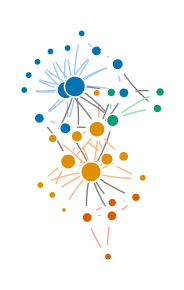

In [24]:
Y = torch.zeros(n, dataset[0].y.max().item() + 1)
for i in range(n):
    Y[i, dataset[0].y[i]] = 1
plot_overlapping(G, S =Y, figsize = (3,3))


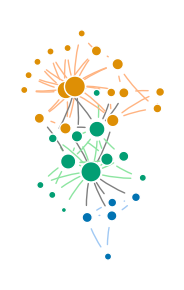

In [25]:
plot_overlapping(G, S =S, figsize = (3,3))

## FastGCN with Neuromap on Karate Club
Let's goooooooooo!
ok so since neuromap already very neatly defines its clusterer etc, it should be easy enough: just pass the FastGCN via the model parameter to the neuromap instance. right??


In [26]:
from fastgcn.helper_functions import *
from fastgcn.fastgcn_model import FastGCN
from fastgcn.updated_fastgcn_model import FastGCNv2

Sooo time to figure out how to adjust these people's code to be compatible with Neuromap ig???

In [27]:
# A clusterer that runs the optimisation.
# The missing ingredient: a specific forward method (next cell).
class Clusterer(torch.nn.Module):
    def __init__(self, model, device: str = "cpu") -> None:
        super().__init__()

        self.model  = model
        self.device = device

    @abstractmethod
    def forward(self, x):
        raise NotImplementedError(f"forward not implemented on {self._get_name()}")

    def fit(self, data: Data, epochs: int, patience: int, lr: float):
        self.data = data.to(self.device)
        x = self.data.x.to_dense()

        l_best : float  = inf  # best loss
        s_best : Tensor = None # best cluster

        optimizer = torch.optim.Adam(self.parameters(), lr = lr)

        epoch          = 0
        no_improvement = 0
    
        while epoch < epochs and no_improvement < patience:
            self.train()
            optimizer.zero_grad()

            loss, s = self.forward(x = x)
            print(f"[Epoch {epoch:4}] L = {loss:.8f} bits")
            loss.backward()
            optimizer.step()

            self.eval()
            with torch.no_grad():
                loss, s = self.forward(x = x)

                if loss < l_best:
                    l_best         = float(loss)
                    no_improvement = 0
                    s_best         = s
                else:
                    no_improvement += 1

                epoch += 1


        return l_best, s_best

In [28]:
# Neuromap inherits from Clusterer and defines the specific forward method.
class Neuromap(Clusterer):
    def __init__(self, model, device: str = "cpu") -> None:
        super().__init__(model = model, device = device)

        # softmax temperature
        self.t = Parameter(torch.zeros(1)).to(device = self.device)


    def forward(self, x):
        s = softmax(self.model(x, self.data.edge_index) / sigmoid(self.t), dim = 1)

        if self.training:
            s = s + 1e-8

        _, _, loss = self.pool(x = x, s = s)

        return loss, s


    def fit(self, data: Data, epochs: int, patience: int, lr: float):
        self.data = data.to(device = self.device)
        self.pool = MapEquationPooling(adj = data.edge_index, device = self.device)
        
        return super().fit(data = data, epochs = epochs, patience = patience, lr = lr)

Ok so this is the FastGCN module. We'll have to mess with the forward function for sure (since the forward pass is defined in the Neuromap clusterer, and we need to make sure the FastGCN forward pass is compatible - also mayyyyybe the duplicate softmax can be removed??)

Not sure how to handle the batch situation? might have to be adjusted too to account for the Neuromap clusterer possibly handling that instead. Let's see.

The main point of incompatibility appears to be that it is not designed to work with torch_geometric.data.Data(), unlike everything else I've seen so far? so let's go and adjust that I guess ://
Also, everything begs the question if Neuromap can handle edge weights?

In [29]:
"""
    FastGCNadjusted: a Neuromap-compatible rewrite of FastGCNv2.

    Neuromap (see example-usage.ipynb) wraps a model and calls it as:

        s = softmax(self.model(x, self.data.edge_index) / sigmoid(self.t), dim=1)

    which means the wrapped model MUST:

      1. Be callable as `model(x, edge_index)` with exactly those two
         positional arguments -- no `csr_mat`, `drop`, `stochastic`,
         `batch_sizes`, or `possible_training_nodes` kwargs.
      2. Treat `edge_index` as a single, full torch.sparse_coo_tensor
         adjacency matrix (that's what `sparse_from_networkx()` /
         `to_dataset()` actually build -- NOT the usual pyg
         `edge_index` of shape [2, num_edges]).
      3. Return RAW logits of shape [num_nodes, output_dim]. Neuromap
         applies its own softmax to the output, so a final
         LogSoftmax/Softmax inside the model would double-activate.
      4. Be constructible *before* any data exists. `Clusterer.__init__`
         stores the model, and `Neuromap.fit()` only builds `self.data`
         (and hence x / edge_index) afterwards -- so nothing in
         `__init__` can depend on `csr_mat` or `x` being available yet.
      5. Use the standard nn.Module convention for dropout (respecting
         `self.training`, toggled by `.train()` / `.eval()`, exactly
         like `torch_geometric.nn.GCN` does) instead of an explicit
         `drop: bool` argument.

    FastGCNadjusted keeps FastGCNv2's layer / batch-norm / dropout
    architecture, but exposes a plain full-batch `forward(x, edge_index)`
    so it can be passed directly as `Neuromap(model=FastGCNadjusted(...))`.

    The original mini-batch sampling machinery
    (`get_subgraphs_concated_sampling`, stochastic forward, precompute
    trick) is kept as optional extras for standalone large-graph use --
    Neuromap never calls any of it, since it always does a full-batch
    pass over the whole graph.
"""

# Import files
import typing

import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn

# Import custom files
from fastgcn.custom_gcn_layers import GCNLayer
from fastgcn.helper_functions import *  # noqa: F401,F403  (brings in csr_to_torch_coo, etc.)


class FastGCNadjusted(nn.Module):
    """
    FastGCN (Chen et al.) rewritten to expose the plain
    `forward(x, edge_index) -> raw_logits` interface that Neuromap
    (and torch_geometric.nn.GCN) expect, while keeping the original
    layer/batch-norm/dropout structure and the optional sampling
    utilities for standalone use.
    """

    def __init__(self,
                 input_dim: int,
                 hidden_dims: typing.Union[int, typing.List[int]],
                 output_dim: int,
                 use_batch_norms: bool = False,
                 dropout: float = 0.0,
                 samp_probs: np.array = None,
                 device: torch.device = torch.device("cpu")):

        # Declare super
        super().__init__()

        # Save the device
        self.device = device
        self.use_batch_norms = use_batch_norms

        # Check hidden dims
        if isinstance(hidden_dims, int):
            hidden_dims = [hidden_dims]
        else:
            pass

        # Set up the layers (identical structure to FastGCNv2)
        layer_list = [GCNLayer(in_channels=input_dim, out_channels=hidden_dims[0], device=self.device)]
        batch_norms = [nn.BatchNorm1d(hidden_dims[0])]
        for i in range(len(hidden_dims) - 1):
            layer_list.append(GCNLayer(in_channels=hidden_dims[i], out_channels=hidden_dims[i + 1], device=self.device))
            batch_norms.append(nn.BatchNorm1d(hidden_dims[i + 1]))
        layer_list.append(GCNLayer(in_channels=hidden_dims[-1], out_channels=output_dim, device=self.device))

        # Create module lists
        self.layers = nn.ModuleList(layer_list).to(self.device)
        self.batch_norms = nn.ModuleList(batch_norms).to(self.device)

        # Activation / dropout. NOTE: no final_activation (no LogSoftmax) --
        # Neuromap applies its own softmax to whatever forward() returns.
        self.drop = nn.Dropout(dropout)
        self.activation = nn.ReLU()

        # Sampling-related state, only used by the optional stochastic
        # helpers below; irrelevant to the Neuromap full-batch path.
        self.samp_probs = samp_probs
        self.rng = np.random.default_rng()

        # Lazily populated by precompute_from(); only needed if you want
        # to reuse the original FastGCN mini-batch precompute trick
        # OUTSIDE of Neuromap. Left as None otherwise.
        self.precompute = None

    # ------------------------------------------------------------------
    # Main entry point -- this is the ONLY thing Neuromap ever calls.
    # ------------------------------------------------------------------
    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:
        """
        Full-batch forward pass, Neuromap-compatible.

        Parameters
        ----------
        x : torch.Tensor
            Dense node-feature matrix, shape [num_nodes, input_dim].
        edge_index : torch.Tensor
            A single torch.sparse_coo_tensor adjacency matrix of shape
            [num_nodes, num_nodes] -- exactly what Neuromap's
            `self.data.edge_index` is (built by `sparse_from_networkx`).

        Returns
        -------
        torch.Tensor
            Raw (pre-softmax) output, shape [num_nodes, output_dim].
        """
        for ind, layer in enumerate(self.layers):
            x = layer(x, edge_index)

            # Batch-norm / activation / dropout on every layer except the
            # last: its raw output is exactly what Neuromap softmaxes.
            if ind < len(self.layers) - 1:
                if self.use_batch_norms:
                    x = self.batch_norms[ind](x)
                x = self.activation(x)
                x = self.drop(x)  # nn.Dropout already respects self.training

        return x

    # ------------------------------------------------------------------
    # Optional extras below, kept for standalone (non-Neuromap) use on
    # large graphs where full-batch training is infeasible. Nothing here
    # is invoked by forward()/Neuromap.
    # ------------------------------------------------------------------

    def precompute_from(self, csr_mat: sp.csr_matrix, x: torch.Tensor) -> None:
        """
        Build the FastGCN "first-hop precompute" (A @ X), the way
        FastGCNv2 did at construction time. Call this yourself if/when
        you want to use `forward_sampled` / `sample_predict` for
        mini-batch training on a large graph -- Neuromap never needs
        or calls this.
        """
        full_adj = csr_to_torch_coo(csr_mat).to(self.device)
        self.precompute = torch.sparse.mm(full_adj, x)

    @torch.no_grad()
    def get_subgraphs_concated_sampling(self, init_batch: typing.List[int], batch_sizes: typing.List[int],
                                         csr_adj_mat: sp.csr_matrix) -> list:
        """Sample from the set of 1-hop neighbors, always including the base nodes.
        Identical to FastGCNv2's method; only used by forward_sampled/sample_predict."""

        batch_sizes = list(batch_sizes)
        batch_sizes.insert(0, 0)

        batch = [init_batch]
        adj_out_mats = []

        all_next_nodes = np.unique(csr_adj_mat[batch[0], :].indices)
        new_nodes = np.setdiff1d(all_next_nodes, batch[0])
        old_nodes = batch[0].copy()

        for i in range(1, len(batch_sizes)):
            denom = sum(self.samp_probs[new_nodes])
            probs = self.samp_probs[new_nodes] / denom

            sampled = self.rng.choice(new_nodes, size=min(batch_sizes[i], len(probs)),
                                       replace=False, p=probs)

            batch.append(np.concatenate((sampled, old_nodes)))

            subgraph_probs = np.concatenate((
                self.samp_probs[sampled] * len(sampled) / self.samp_probs[sampled].sum(),
                np.ones(old_nodes.shape)
            ))

            adj_out_mats.append(csr_to_torch_coo(
                csr_adj_mat[batch[i - 1], :][:, batch[i]].multiply(1. / subgraph_probs)).to(self.device))

            all_next_nodes = np.unique(csr_adj_mat[sampled, :].indices)
            new_nodes = np.setdiff1d(all_next_nodes, sampled)
            old_nodes = sampled.copy()

        adj_out_mats.append(batch[-1])

        return adj_out_mats[::-1]

    def forward_sampled(self, csr_mat: sp.csr_matrix, batch_sizes: typing.List[int],
                         possible_training_nodes: list) -> tuple:
        """
        Optional FastGCN-style stochastic mini-batch forward pass.
        Requires `precompute_from()` to have been called first.
        Not used by Neuromap.
        """
        if self.precompute is None:
            raise RuntimeError("Call precompute_from(csr_mat, x) before forward_sampled().")

        init_batch = self.rng.choice(possible_training_nodes, size=batch_sizes[0], replace=False)
        batch_adjs = self.get_subgraphs_concated_sampling(init_batch=init_batch,
                                                           batch_sizes=batch_sizes[1:],
                                                           csr_adj_mat=csr_mat)

        x = None
        for ind, layer in enumerate(self.layers):
            if ind == 0:
                data = self.precompute[batch_adjs[ind]].to(self.device)
                x = layer.precomputed_forward(data)
            else:
                x = layer(x, batch_adjs[ind])

            if ind < len(self.layers) - 1:
                if self.use_batch_norms:
                    x = self.batch_norms[ind](x)
                x = self.activation(x)
                x = self.drop(x)

        return x, init_batch

    @torch.no_grad()
    def predict(self, x: torch.Tensor, edge_index: torch.Tensor) -> tuple:
        """Predict the class for a given set of points (full batch)."""
        was_training = self.training
        self.eval()
        out = self.forward(x, edge_index)
        pred = torch.argmax(out, dim=1)
        self.train(was_training)
        return pred, out

    @torch.no_grad()
    def sample_predict(self, csr_mat: sp.csr_matrix,
                        init_batch: typing.List[int],
                        batch_sizes: typing.List[int],
                        num_inference_times: int = 1) -> tuple:
        """Perform mini-batch inference using sampled nodes (requires precompute_from() first)."""
        if self.precompute is None:
            raise RuntimeError("Call precompute_from(csr_mat, x) before sample_predict().")

        was_training = self.training
        self.eval()

        final_res = 0
        for _ in range(num_inference_times):
            batch_adjs = self.get_subgraphs_concated_sampling(init_batch=init_batch,
                                                               batch_sizes=batch_sizes[1:],
                                                               csr_adj_mat=csr_mat)
            out = None
            for ind, layer in enumerate(self.layers):
                if ind == 0:
                    out = layer.precomputed_forward(self.precompute[batch_adjs[ind]])
                else:
                    out = layer(out, batch_adjs[ind])

                if ind < len(self.layers) - 1:
                    if self.use_batch_norms:
                        out = self.batch_norms[ind](out)
                    out = self.activation(out)

            final_res += out

        final_res = final_res / num_inference_times
        pred = torch.argmax(final_res, dim=1)

        self.train(was_training)
        return pred, final_res, init_batch

In [34]:
# ------------------------------------------------
# Declare the model and optimizer
model = FastGCNadjusted(input_dim=n,
                        hidden_dims=n, 
                        output_dim=n, 
                        dropout=0.5,
                        samp_probs=np.ones(n,), # corresponds to uniform, but needs to be adjusted later!!!!!!!
                        device=device,
                        use_batch_norms=True
                )
print(f"Your model:\n{model}")

Your model:
FastGCNadjusted(
  (layers): ModuleList(
    (0-1): 2 x GCNLayer()
  )
  (batch_norms): ModuleList(
    (0): BatchNorm1d(34, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (drop): Dropout(p=0.5, inplace=False)
  (activation): ReLU()
)


In [35]:
neuromap = Neuromap(model = model, device = "cpu")
print(neuromap)

Neuromap(
  (model): FastGCNadjusted(
    (layers): ModuleList(
      (0-1): 2 x GCNLayer()
    )
    (batch_norms): ModuleList(
      (0): BatchNorm1d(34, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (drop): Dropout(p=0.5, inplace=False)
    (activation): ReLU()
  )
)


In [36]:
L, S = neuromap.fit(data, epochs = 1000, patience = 100, lr = 1e-1)

[Epoch    0] L = 5.84093428 bits
[Epoch    1] L = 5.00792694 bits
[Epoch    2] L = 4.51070452 bits
[Epoch    3] L = 4.55408669 bits
[Epoch    4] L = 4.52022409 bits
[Epoch    5] L = 4.55338526 bits
[Epoch    6] L = 4.47078609 bits
[Epoch    7] L = 4.42408466 bits
[Epoch    8] L = 4.40932465 bits
[Epoch    9] L = 4.42408419 bits
[Epoch   10] L = 4.42062187 bits
[Epoch   11] L = 4.40932465 bits
[Epoch   12] L = 4.66157103 bits
[Epoch   13] L = 4.40932465 bits
[Epoch   14] L = 4.40932417 bits
[Epoch   15] L = 4.40932560 bits
[Epoch   16] L = 4.46213722 bits
[Epoch   17] L = 4.40932465 bits
[Epoch   18] L = 4.40932465 bits
[Epoch   19] L = 4.40932465 bits
[Epoch   20] L = 4.51946640 bits
[Epoch   21] L = 4.40932465 bits
[Epoch   22] L = 4.40986204 bits
[Epoch   23] L = 4.40932465 bits
[Epoch   24] L = 4.46375751 bits
[Epoch   25] L = 4.55338287 bits
[Epoch   26] L = 4.40932465 bits
[Epoch   27] L = 4.48465014 bits
[Epoch   28] L = 4.55548525 bits
[Epoch   29] L = 4.55338383 bits
[Epoch   3

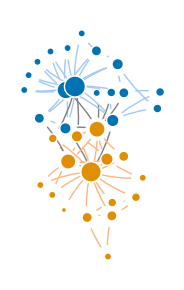

In [37]:
plot_overlapping(G, S = S, figsize = (3,3))

hmmmm.... I'll have to inspect this further for sure

In [44]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
    FastGCNnew: a re-implementation of FastGCN (Chen, Ma & Xiao, ICLR 2018,
    "FastGCN: Fast Learning with Graph Convolutional Networks via Importance
    Sampling") that follows the same class structure/API as
    torch_geometric.nn.models.GraphSAGE (i.e. the BasicGNN family).

    Original algorithmic logic (layer-wise importance sampling, the
    "concatenated" sampling scheme that always keeps the previous layer's
    nodes, and the AX pre-computation trick) is ported from the uploaded
    fastgcn-pytorch implementation (custom_gcn_layers.py, fastgcn_model.py,
    updated_fastgcn_model.py, helper_functions.py), which is itself an
    implementation of https://github.com/gmancino/fastgcn-pytorch.

    Why a rewrite is necessary
    ---------------------------
    GCN and GraphSAGE in PyTorch Geometric share a common `BasicGNN`
    interface:

        model = GraphSAGE(in_channels, hidden_channels, num_layers,
                           out_channels=..., dropout=..., act=..., norm=...)
        out = model(x, edge_index)                       # full batch
        out = model.inference(x_all, subgraph_loader)     # mini-batch / test

    The uploaded FastGCN code instead takes a `scipy.sparse.csr_matrix`,
    builds the model around a specific dataset at construction time
    (`csr_mat`, `x` are required __init__ args), and has a `forward` whose
    signature/return type (`Tuple[Tensor, sampled_batch_indices]`) has
    nothing in common with GraphSAGE. That makes it impossible to swap
    between GCN / GraphSAGE / FastGCN in a benchmarking loop without
    special-casing FastGCN everywhere.

    FastGCNnew below fixes this: it exposes the same constructor shape,
    the same `forward(x, edge_index)` signature returning a plain Tensor,
    and the same `inference(x_all, subgraph_loader)` pattern used by PyG's
    BasicGNN models -- while still performing genuine FastGCN layer-wise
    importance sampling internally (not neighbor sampling a la GraphSAGE).
"""

# Import files
import copy
from typing import Any, Callable, Dict, List, Optional, Union

import numpy as np
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

try:
    # Only used for type hints / optional mini-batch inference support;
    # FastGCNnew does not require torch_geometric to be installed for
    # training, only for converting a PyG-style edge_index into a CSR
    # matrix and (optionally) for typing the NeighborLoader in inference().
    from torch_geometric.utils import to_scipy_sparse_matrix
except ImportError:  # pragma: no cover
    to_scipy_sparse_matrix = None


# --------------------------------------------------------------------------
# Layer: a GCN-style linear-and-propagate layer, identical in spirit to
# custom_gcn_layers.GCNLayer, but written against dense/sparse `Tensor`
# adjacency blocks the way the rest of the FastGCN sampler builds them,
# and named/shaped so it slots into a ModuleList exactly like SAGEConv.
# --------------------------------------------------------------------------
class FastGCNConv(nn.Module):
    """
    A single FastGCN propagation + linear layer.

    forward(x, adj) computes  activation-free  adj @ x @ W + b, where `adj`
    is EITHER the (sampled, importance-reweighted) bipartite adjacency
    block between consecutive sampled layers, OR, for the first layer, may
    be skipped entirely in favor of `forward_precomputed`, mirroring
    GCNLayer.precomputed_forward in the uploaded code.
    """

    def __init__(self, in_channels: int, out_channels: int, bias: bool = True):
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels

        self.weight = nn.Parameter(torch.empty(in_channels, out_channels))
        if bias:
            self.bias = nn.Parameter(torch.empty(out_channels))
        else:
            self.register_parameter("bias", None)

        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.weight)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, x: Tensor, adj: torch.sparse.Tensor) -> Tensor:
        """Propagate then transform: (adj @ x) @ W + b."""
        out = torch.sparse.mm(adj, x) if adj.is_sparse else torch.mm(adj, x)
        out = torch.mm(out, self.weight)
        if self.bias is not None:
            out = out + self.bias
        return out

    def forward_precomputed(self, ax: Tensor) -> Tensor:
        """Transform only, assuming `adj @ x` has already been computed."""
        out = torch.mm(ax, self.weight)
        if self.bias is not None:
            out = out + self.bias
        return out

    def __repr__(self) -> str:
        return f"{self.__class__.__name__}({self.in_channels}, {self.out_channels})"


# --------------------------------------------------------------------------
# Helper: layer-wise importance sampler, ported from
# FastGCN.get_subgraphs_concated_sampling / FastGCNv2's version. Split out
# into its own class so FastGCNnew's forward/inference can stay close to
# BasicGNN's, and so the sampler is independently testable/reusable.
# --------------------------------------------------------------------------
class FastGCNSampler:
    """
    Implements the layer-wise importance sampling distribution from the
    FastGCN paper (q(v) ~ ||A[:, v]||^2, passed in as `samp_probs`) together
    with the "concatenated" sampling scheme used in the uploaded reference
    code: each sampled layer is the union of a newly importance-sampled set
    of 1-hop neighbors and the previous layer's node set (so information
    already computed is never re-sampled away), with edge weights rescaled
    by the inverse sampling probability to keep the estimator unbiased.
    """

    def __init__(self, csr_adj: sp.csr_matrix, samp_probs: np.ndarray, rng: Optional[np.random.Generator] = None):
        self.csr_adj = csr_adj
        self.samp_probs = samp_probs
        self.rng = rng if rng is not None else np.random.default_rng()

    def sample(self, init_batch: np.ndarray, layer_sizes: List[int], device: torch.device) -> List[Union[torch.sparse.Tensor, np.ndarray]]:
        """
        Build the per-layer sampled adjacency blocks needed for one forward
        pass seeded on `init_batch` (the target/output nodes).

        Returns a list ordered from INPUT layer to OUTPUT layer:
            [node_ids_for_layer_0 (np.ndarray),
             sparse_adj_block_1, sparse_adj_block_2, ..., sparse_adj_block_L]
        where sparse_adj_block_i connects the sampled nodes of layer i-1 to
        layer i. This matches the structure returned by
        get_subgraphs_concated_sampling in the uploaded implementation.
        """
        batch = [init_batch]
        adj_out_mats = []

        all_next_nodes = np.unique(self.csr_adj[batch[0], :].indices)
        new_nodes = np.setdiff1d(all_next_nodes, batch[0])
        old_nodes = batch[0].copy()

        for i in range(1, len(layer_sizes) + 1):
            denom = self.samp_probs[new_nodes].sum()
            probs = self.samp_probs[new_nodes] / denom

            n_sample = min(layer_sizes[i - 1], len(probs))
            sampled = self.rng.choice(new_nodes, size=n_sample, replace=False, p=probs)

            batch.append(np.concatenate((sampled, old_nodes)))

            subgraph_probs = np.concatenate((
                self.samp_probs[sampled] * len(sampled) / denom,
                np.ones(old_nodes.shape),
            ))

            adj_block = csr_to_torch_coo(
                self.csr_adj[batch[i - 1], :][:, batch[i]].multiply(1.0 / subgraph_probs)
            ).to(device)
            adj_out_mats.append(adj_block)

            all_next_nodes = np.unique(self.csr_adj[sampled, :].indices)
            new_nodes = np.setdiff1d(all_next_nodes, sampled)
            old_nodes = sampled.copy()

        adj_out_mats.append(batch[-1])
        return adj_out_mats[::-1]


# --------------------------------------------------------------------------
# Small standalone helpers (kept local instead of importing
# models.helper_functions, since FastGCNnew is meant to be self-contained
# and importable the same way GraphSAGE is).
# --------------------------------------------------------------------------
def csr_to_torch_coo(adj: sp.spmatrix) -> torch.sparse.Tensor:
    """Convert a scipy sparse matrix to a torch sparse COO tensor."""
    if not sp.isspmatrix_coo(adj):
        adj = sp.coo_matrix(adj)
    return torch.sparse_coo_tensor(
        indices=np.array([adj.row, adj.col]),
        values=adj.data,
        size=adj.shape,
        dtype=torch.float32,
    )


def normalize_adj(adj: sp.spmatrix) -> sp.csr_matrix:
    """Symmetric normalization D^-1/2 A D^-1/2, as used by Kipf & Welling / FastGCN."""
    if not sp.isspmatrix_coo(adj):
        adj = sp.coo_matrix(adj)
    rowsum = np.array(adj.sum(1)).flatten()
    d_inv_sqrt = np.zeros_like(rowsum, dtype=np.float64)
    nonzero = rowsum > 0
    d_inv_sqrt[nonzero] = np.power(rowsum[nonzero], -0.5)
    d_mat_inv_sqrt = sp.diags(d_inv_sqrt)
    return adj.dot(d_mat_inv_sqrt).transpose().dot(d_mat_inv_sqrt).tocsr()


def compute_sampling_probs(csr_adj: sp.csr_matrix) -> np.ndarray:
    """
    Default FastGCN importance distribution: q(v) proportional to the
    squared column norm of the (normalized) adjacency matrix, as defined
    in the FastGCN paper (Eq. 6-8). Callers may compute/supply their own
    `samp_probs` (e.g. uniform, or precomputed once for a large graph) via
    FastGCNnew(..., samp_probs=...).
    """
    col_norms_sq = np.array(csr_adj.power(2).sum(axis=0)).flatten()
    probs = col_norms_sq / col_norms_sq.sum()
    return probs


def edge_index_to_csr(edge_index: Tensor, num_nodes: int) -> sp.csr_matrix:
    """
    Convert a PyG-style `edge_index` (2, num_edges) LongTensor into a
    scipy CSR adjacency matrix, so FastGCNnew can accept exactly the same
    `(x, edge_index)` inputs as GraphSAGE while still sampling/propagating
    with scipy/numpy internally (as the original FastGCN code does).
    """
    if to_scipy_sparse_matrix is not None:
        return to_scipy_sparse_matrix(edge_index, num_nodes=num_nodes).tocsr()

    row, col = edge_index.cpu().numpy()
    data = np.ones(row.shape[0], dtype=np.float32)
    return sp.csr_matrix((data, (row, col)), shape=(num_nodes, num_nodes))


# --------------------------------------------------------------------------
# Main model: mirrors torch_geometric.nn.models.GraphSAGE's public API.
# --------------------------------------------------------------------------
class FastGCNnew(nn.Module):
    """
    The Graph Neural Network from the `"FastGCN: Fast Learning with Graph
    Convolutional Networks via Importance Sampling"
    <https://arxiv.org/abs/1801.10247>`_ paper, restructured to match the
    constructor/forward/inference API of
    :class:`torch_geometric.nn.models.GraphSAGE` (and the rest of the
    :class:`~torch_geometric.nn.models.basic_gnn.BasicGNN` family), so it
    can be dropped into a benchmark alongside PyG's ``GCN`` and
    ``GraphSAGE`` with no special-casing.

    Unlike GraphSAGE (which neighbor-samples uniformly at each layer),
    FastGCN performs *layer-wise importance sampling*: at every layer it
    draws a fixed-size sample of nodes from a precomputed importance
    distribution ``q(v)`` proportional to the squared column norms of the
    adjacency matrix, and reweights the sampled adjacency block by the
    inverse sampling probability to keep the layer-wise estimator
    unbiased. This is what makes FastGCN's per-batch cost independent of
    the graph's degree distribution, unlike neighbor sampling.

    Args:
        in_channels (int): Size of each input sample.
        hidden_channels (int): Size of each hidden sample.
        num_layers (int): Number of message passing layers.
        out_channels (int, optional): If given, the last layer maps to
            this size and a separate output layer is used, matching
            BasicGNN's behavior. (default: :obj:`None`)
        dropout (float, optional): Dropout probability. (default: :obj:`0.0`)
        act (str or Callable, optional): Activation function.
            (default: :obj:`"relu"`)
        norm (torch.nn.Module or "batch_norm", optional): Normalization
            layer applied after each hidden layer; a fresh copy is created
            per layer, matching BasicGNN's `norm` handling.
            (default: :obj:`None`)
        batch_size (int, optional): Number of target/root nodes sampled
            per stochastic forward pass when the model is called with
            ``sample=True`` (i.e. FastGCN's own equivalent of
            GraphSAGE's `NeighborLoader` batch size). (default: :obj:`256`)
        layer_sizes (List[int], optional): Number of nodes sampled at each
            of the `num_layers` propagation steps (ordered from the layer
            nearest the input to the layer nearest the output). If not
            given, defaults to ``[batch_size] * num_layers``, mirroring
            the FastGCN paper's fixed per-layer sample size.
        samp_probs (np.ndarray, optional): Precomputed FastGCN importance
            distribution over nodes. If not given, it is computed
            automatically from the graph the first time `forward` or
            `inference` is called with `sample=True`, following Eq. 6-8 of
            the FastGCN paper.
        bias (bool, optional): Whether to add a learnable bias.
            (default: :obj:`True`)
        **kwargs (optional): Additional keyword arguments (accepted for
            interface parity with BasicGNN's `**kwargs`, currently unused).
    """

    def __init__(
        self,
        in_channels: int,
        hidden_channels: int,
        num_layers: int,
        out_channels: Optional[int] = None,
        dropout: float = 0.0,
        act: Union[str, Callable, None] = "relu",
        norm: Optional[Union[str, nn.Module]] = None,
        batch_size: int = 256,
        layer_sizes: Optional[List[int]] = None,
        samp_probs: Optional[np.ndarray] = None,
        bias: bool = True,
        **kwargs: Any,
    ):
        super().__init__()

        self.in_channels = in_channels
        self.hidden_channels = hidden_channels
        self.num_layers = num_layers
        self.dropout = nn.Dropout(dropout)
        self.batch_size = batch_size
        self.layer_sizes = layer_sizes if layer_sizes is not None else [batch_size] * num_layers
        assert len(self.layer_sizes) == num_layers, "layer_sizes must have length num_layers"

        self.samp_probs = samp_probs
        self.rng = np.random.default_rng()

        # Resolve activation, mirroring BasicGNN.act_resolver but kept
        # dependency-free (no torch_geometric.nn.resolver requirement).
        if isinstance(act, str):
            self.act = getattr(F, act)
        elif callable(act) or act is None:
            self.act = act if act is not None else (lambda x: x)
        else:
            raise ValueError(f"Unsupported activation: {act}")
        self.final_activation = nn.LogSoftmax(dim=-1)

        # Build the conv stack, exactly like BasicGNN: `out_channels`
        # (if given) becomes a distinct final layer's output size.
        self.out_channels = out_channels if out_channels is not None else hidden_channels

        self.convs = nn.ModuleList()
        if num_layers == 1:
            self.convs.append(FastGCNConv(in_channels, self.out_channels, bias=bias))
        else:
            self.convs.append(FastGCNConv(in_channels, hidden_channels, bias=bias))
            for _ in range(num_layers - 2):
                self.convs.append(FastGCNConv(hidden_channels, hidden_channels, bias=bias))
            self.convs.append(FastGCNConv(hidden_channels, self.out_channels, bias=bias))

        # One norm layer per hidden conv (not applied after the final
        # layer), matching BasicGNN's `self.norms` handling.
        self.norms = nn.ModuleList()
        num_norm_layers = num_layers - 1 if out_channels is not None else num_layers
        for _ in range(num_norm_layers):
            if norm == "batch_norm":
                self.norms.append(nn.BatchNorm1d(hidden_channels))
            elif isinstance(norm, nn.Module):
                self.norms.append(copy.deepcopy(norm))
            else:
                self.norms.append(nn.Identity())

        # Cached full-graph state, populated lazily the first time a CSR/
        # edge_index is seen, mirroring FastGCN's `self.full_adj` /
        # `self.precompute`. Kept as buffers-by-hand (not registered
        # tensors) since their shape depends on the input graph and isn't
        # known at construction time -- same reason the uploaded
        # implementation takes `csr_mat`/`x` in __init__, except here we
        # defer that requirement so the constructor matches GraphSAGE's.
        self._csr_adj: Optional[sp.csr_matrix] = None
        self._full_adj: Optional[torch.sparse.Tensor] = None
        self._precompute: Optional[Tensor] = None
        self._sampler: Optional[FastGCNSampler] = None

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for norm in self.norms:
            if hasattr(norm, "reset_parameters"):
                norm.reset_parameters()

    # ----------------------------------------------------------------
    # Internal: (re)build cached full-graph adjacency / precomputation
    # whenever the input graph changes. Cheap to check, expensive to
    # skip incorrectly, so we key the cache off object identity of the
    # edge_index/csr the caller passed in.
    # ----------------------------------------------------------------
    def _prepare_graph(self, x: Tensor, edge_index: Union[Tensor, sp.csr_matrix], num_nodes: Optional[int] = None):
        if isinstance(edge_index, Tensor):
            num_nodes = num_nodes if num_nodes is not None else x.size(0)
            csr_adj = edge_index_to_csr(edge_index, num_nodes)
        else:
            csr_adj = edge_index if sp.isspmatrix_csr(edge_index) else edge_index.tocsr()

        csr_adj = normalize_adj(csr_adj)

        self._csr_adj = csr_adj
        self._full_adj = csr_to_torch_coo(csr_adj).to(x.device)
        self._precompute = torch.sparse.mm(self._full_adj, x)

        if self.samp_probs is None:
            self.samp_probs = compute_sampling_probs(csr_adj)
        self._sampler = FastGCNSampler(csr_adj, self.samp_probs, self.rng)

    def _apply_layer(self, x: Tensor, layer_idx: int, adj_or_ax: Union[Tensor, torch.sparse.Tensor], precomputed: bool) -> Tensor:
        conv = self.convs[layer_idx]
        x = conv.forward_precomputed(adj_or_ax) if precomputed else conv(x, adj_or_ax)

        is_last = layer_idx == len(self.convs) - 1
        if not is_last:
            if layer_idx < len(self.norms):
                x = self.norms[layer_idx](x)
            x = self.act(x)
            x = self.dropout(x)
        return x

    # ----------------------------------------------------------------
    # Public API -- matches BasicGNN.forward / BasicGNN.inference.
    # ----------------------------------------------------------------
    def forward(
        self,
        x: Tensor,
        edge_index: Union[Tensor, sp.csr_matrix],
        sample: bool = False,
        batch_nodes: Optional[np.ndarray] = None,
    ) -> Tensor:
        """
        Full-graph (transductive) or stochastic (FastGCN-sampled) forward
        pass, matching GraphSAGE's ``forward(x, edge_index)`` signature.

        Args:
            x: Node feature matrix.
            edge_index: Either a PyG-style ``(2, num_edges)`` LongTensor,
                or a precomputed ``scipy.sparse.csr_matrix`` adjacency
                (useful to avoid re-normalizing/re-converting every call
                during training).
            sample (bool): If :obj:`True`, performs one stochastic FastGCN
                forward pass over ``batch_nodes`` (or a fresh random batch
                of size ``self.batch_size`` if not given) instead of a
                full-graph pass, mirroring the ``stochastic=True`` path of
                the uploaded implementation's ``forward``.
            batch_nodes: Target node indices for a stochastic pass.
                Ignored if ``sample=False``.

        Returns:
            Log-softmax class scores, shaped ``[num_target_nodes,
            out_channels]`` (``num_target_nodes`` is all nodes for a
            full-graph pass, or ``len(batch_nodes)`` for a sampled pass).
        """
        self._prepare_graph(x, edge_index)

        if not sample:
            h = self._precompute
            for i in range(len(self.convs)):
                if i == 0:
                    h = self._apply_layer(h, 0, self._precompute, precomputed=True)
                else:
                    h = self._apply_layer(h, i, self._full_adj, precomputed=False)
            return self.final_activation(h)

        return self._sampled_forward(batch_nodes)

    def _sampled_forward(self, batch_nodes: Optional[np.ndarray]) -> Tensor:
        if batch_nodes is None:
            batch_nodes = self.rng.choice(self._csr_adj.shape[0], size=self.batch_size, replace=False)

        sampled = self._sampler.sample(np.asarray(batch_nodes), self.layer_sizes, device=self._precompute.device)
        # sampled = [layer0_node_ids, adj_block_1, ..., adj_block_L]
        layer0_ids, adj_blocks = sampled[0], sampled[1:]

        h = self._precompute[layer0_ids]
        for i, adj in enumerate(adj_blocks):
            h = self._apply_layer(h, i, adj, precomputed=False)
        return self.final_activation(h)

    @torch.no_grad()
    def inference(
        self,
        x_all: Tensor,
        subgraph_loader: Any,
        device: Optional[torch.device] = None,
    ) -> Tensor:
        """
        Full-graph inference in evaluation mode, matching the signature of
        BasicGNN.inference(x_all, subgraph_loader): scores every node in
        ``x_all`` using the complete (unsampled) graph, layer by layer, so
        it can be called identically to ``GraphSAGE.inference`` /
        ``GCN.inference`` in an evaluation loop that iterates architectures.

        ``subgraph_loader`` may be:
          * a PyG ``NeighborLoader``/``LinkNeighborLoader``-style object
            exposing ``.data.edge_index`` (or ``.edge_index``) covering the
            full graph, in which case the full adjacency is rebuilt from
            it, or
          * ``None``, in which case the adjacency cached from the most
            recent ``forward`` call is reused.
        """
        device = device if device is not None else x_all.device
        self.eval()

        if subgraph_loader is not None:
            edge_index = getattr(subgraph_loader, "edge_index", None)
            if edge_index is None and hasattr(subgraph_loader, "data"):
                edge_index = subgraph_loader.data.edge_index
            if edge_index is not None:
                self._prepare_graph(x_all.to(device), edge_index.to(device), num_nodes=x_all.size(0))

        if self._precompute is None:
            raise RuntimeError(
                "FastGCNnew.inference called with no cached graph and no "
                "usable subgraph_loader; call forward() at least once, or "
                "pass a subgraph_loader exposing `edge_index`."
            )

        h = self._precompute
        for i in range(len(self.convs)):
            if i == 0:
                h = self._apply_layer(h, 0, self._precompute, precomputed=True)
            else:
                h = self._apply_layer(h, i, self._full_adj, precomputed=False)
        return self.final_activation(h)

    @torch.no_grad()
    def predict(self, x: Tensor, edge_index: Union[Tensor, sp.csr_matrix]) -> Tensor:
        """Convenience wrapper returning hard class predictions (argmax)."""
        self.eval()
        out = self.forward(x, edge_index, sample=False)
        return out.argmax(dim=-1)

    def __repr__(self) -> str:
        return (
            f"{self.__class__.__name__}({self.in_channels}, "
            f"{self.hidden_channels}, num_layers={self.num_layers}, "
            f"out_channels={self.out_channels})"
        )

In [47]:
model = FastGCNnew(in_channels = n,
                   hidden_channels = n,
                   num_layers = 2,
                   out_channels = n,
                   dropout= 0.5,
                   act = "selu")

print(f"Your model:\n{model}")

neuromap = Neuromap(model = model, device = "cpu")

Your model:
FastGCNnew(34, 34, num_layers=2, out_channels=34)


In [48]:
L, S = neuromap.fit(data, epochs = 1000, patience = 100, lr = 1e-1)

ValueError: too many values to unpack (expected 2)

In [ ]:
plot_overlapping(G, S = S, figsize = (3,3))